# VRPTW Demo: ¿Por qué necesitamos la Dimensión de Tiempo?

En este ejemplo vamos a comparar dos enfoques:
1.  **Modelo por Distancia**: Solo le importan los kilómetros recorridos. Ignora cuándo llega al cliente.
2.  **Modelo VRPTW**: Optimiza por distancia pero respeta rígidamente las **Ventanas Horarias (Time Windows)**.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

def create_data_model():
    """Genera datos sintéticos: 1 Depósito, 1 Planta, 5 Clientes."""
    data = {}
    # Coordenadas (x, y) para visualización
    data['locations'] = [
        (50, 50),   # 0: Depot (Centro)
        (50, 80),   # 1: Plant (Norte)
        (10, 10),   # 2: Customer 1 (Suroeste - Lejos)
        (20, 30),   # 3: Customer 2
        (80, 20),   # 4: Customer 3
        (90, 80),   # 5: Customer 4 (Noreste)
        (70, 40),   # 6: Customer 5
    ]
    # 0=Depot, 1=Plant, 2-6=Customers
    data['time_windows'] = [
        (0, 1440),   # Depósito: 24h
        (0, 1440),   # Planta: 24h
        (480, 600),  # Cliente 1: 08:00 - 10:00 (VENTANA TEMPRANA CRÍTICA)
        (480, 1080), # Cliente 2: 08:00 - 18:00
        (480, 1080), # Cliente 3: 08:00 - 18:00
        (900, 1020), # Cliente 4: 15:00 - 17:00 (VENTANA TARDÍA)
        (480, 1080), # Cliente 5: 08:00 - 18:00
    ]
    data['service_time'] = 30 # 30 mins por descarga
    
    # Generamos matriz de tiempos basada en distancia Euclídea (minutos = distancia * 1.5)
    num_locations = len(data['locations'])
    data['time_matrix'] = []
    for i in range(num_locations):
        row = []
        for j in range(num_locations):
            if i == j:
                row.append(0)
            else:
                dist = np.sqrt((data['locations'][i][0]-data['locations'][j][0])**2 + 
                               (data['locations'][i][1]-data['locations'][j][1])**2)
                row.append(int(dist * 1.5))
        data['time_matrix'].append(row)
        
    data['num_vehicles'] = 1
    data['depot'] = 0
    return data

def print_solution(data, manager, routing, solution):
    """Visualiza el resultado en consola."""
    if not solution:
        print("¡Error! No se encontró una solución factible.")
        return []
        
    time_dimension = routing.GetDimensionOrDie('Time')
    route_data = []
    
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        plan_output = f'Ruta para vehículo {vehicle_id}:\n'
        while not routing.IsEnd(index):
            time_var = time_dimension.CumulVar(index)
            node = manager.IndexToNode(index)
            arrival = solution.Min(time_var)
            plan_output += f' -> Nodo {node} (Llegada: {arrival//60:02d}:{arrival%60:02d})'
            route_data.append({'node': node, 'arrival': arrival, 'window': data['time_windows'][node], 'coords': data['locations'][node]})
            index = solution.Value(routing.NextVar(index))
        
        time_var = time_dimension.CumulVar(index)
        node = manager.IndexToNode(index)
        arrival = solution.Min(time_var)
        plan_output += f' -> Fin Nodo {node} (Retorno: {arrival//60:02d}:{arrival%60:02d})\n'
        route_data.append({'node': node, 'arrival': arrival, 'window': data['time_windows'][node], 'coords': data['locations'][node]})
        print(plan_output)
    return route_data

### Caso 1: Optimización ignorando Tiempo (Fase 1)
El solver solo busca el camino más corto.

In [22]:
data = create_data_model()
manager = pywrapcp.RoutingIndexManager(len(data['time_matrix']), data['num_vehicles'], data['depot'])
routing = pywrapcp.RoutingModel(manager)

def time_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    service = data['service_time'] if from_node >= 2 else 0
    return data['time_matrix'][from_node][to_node] + service

transit_callback_index = routing.RegisterTransitCallback(time_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
routing.AddDimension(transit_callback_index, 1440, 1440, True, 'Time')

search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC

solution = routing.SolveWithParameters(search_parameters)
print("--- RESULTADO POR DISTANCIA (IGNORANDO VENTANAS) ---")
route_dist_only = print_solution(data, manager, routing, solution)

--- RESULTADO POR DISTANCIA (IGNORANDO VENTANAS) ---
Ruta para vehículo 0:
 -> Nodo 0 (Llegada: 00:00) -> Nodo 3 (Llegada: 00:54) -> Nodo 2 (Llegada: 01:57) -> Nodo 4 (Llegada: 04:13) -> Nodo 6 (Llegada: 05:16) -> Nodo 5 (Llegada: 06:53) -> Nodo 1 (Llegada: 08:23) -> Fin Nodo 0 (Retorno: 09:08)



### Caso 2: Optimización con Ventanas Horarias (Fase 2)
Obligamos al solver a llegar dentro de las franjas pactadas.

In [23]:
data = create_data_model()
manager = pywrapcp.RoutingIndexManager(len(data['time_matrix']), data['num_vehicles'], data['depot'])
routing = pywrapcp.RoutingModel(manager)
transit_callback_index = routing.RegisterTransitCallback(time_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

routing.AddDimension(transit_callback_index, 1440, 1440, True, 'Time')
time_dimension = routing.GetDimensionOrDie('Time')

for location_idx, window in enumerate(data['time_windows']):
    index = manager.NodeToIndex(location_idx)
    time_dimension.CumulVar(index).SetRange(window[0], window[1])

search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC

solution = routing.SolveWithParameters(search_parameters)
print("--- RESULTADO VRPTW (RESPETANDO VENTANAS) ---")
route_windows = print_solution(data, manager, routing, solution)

--- RESULTADO VRPTW (RESPETANDO VENTANAS) ---
Ruta para vehículo 0:
 -> Nodo 0 (Llegada: 00:00) -> Nodo 3 (Llegada: 08:00) -> Nodo 2 (Llegada: 09:03) -> Nodo 4 (Llegada: 11:19) -> Nodo 6 (Llegada: 12:22) -> Nodo 5 (Llegada: 15:00) -> Nodo 1 (Llegada: 16:30) -> Fin Nodo 0 (Retorno: 17:15)



### Visualización de Cumplimiento

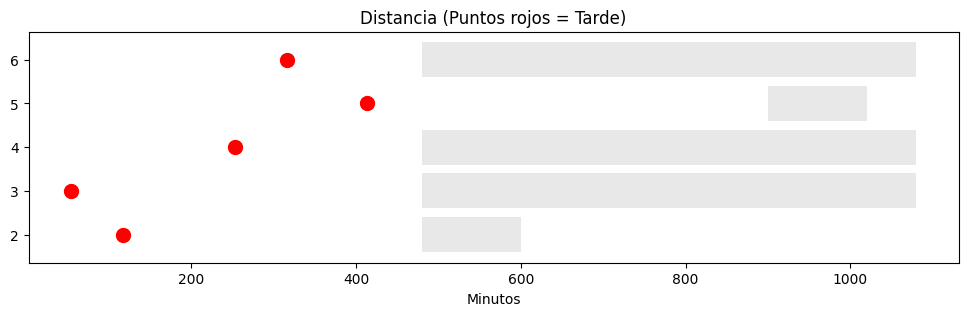

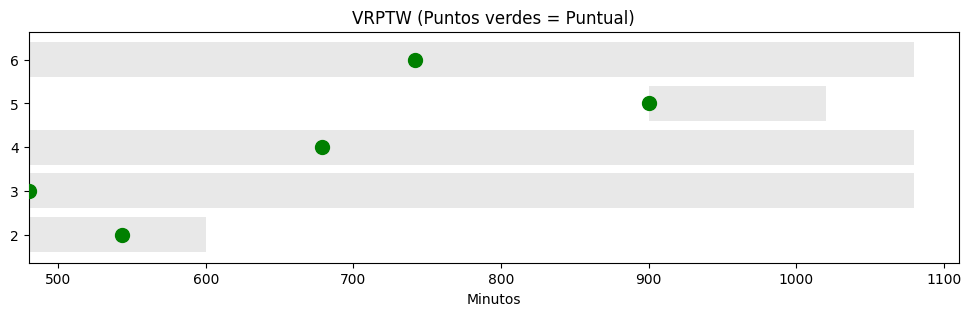

In [24]:
def plot_timeline(route_data, title):
    if not route_data:
        return
    fig, ax = plt.subplots(figsize=(12, 3))
    for stop in route_data:
        node = stop['node']
        if node < 2: continue
        ax.barh(node, stop['window'][1]-stop['window'][0], left=stop['window'][0], color='lightgray', alpha=0.5)
        color = 'green' if stop['window'][0] <= stop['arrival'] <= stop['window'][1] else 'red'
        ax.scatter(stop['arrival'], node, color=color, s=100, zorder=5)
    ax.set_xlabel("Minutos")
    ax.set_title(title)
    plt.show()

plot_timeline(route_dist_only, "Distancia (Puntos rojos = Tarde)")
plot_timeline(route_windows, "VRPTW (Puntos verdes = Puntual)")

### Animación de las Entregas
Vamos a ver al camión moviéndose por el mapa sintético.

In [25]:
def animate_route(route_data, title):
    if not route_data: return
    
    coords = [stop['coords'] for stop in route_data]
    x_vals, y_vals = zip(*coords)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_title(title)
    
    # Dibujar todos los puntos
    all_coords = create_data_model()['locations']
    ax.scatter([c[0] for c in all_coords], [c[1] for c in all_coords], color='blue', alpha=0.3)
    for i, (x, y) in enumerate(all_coords):
        ax.text(x+2, y+2, f"N{i}", fontsize=9)

    line, = ax.plot([], [], 'r-', lw=2, alpha=0.6)
    point = ax.scatter([], [], color='red', s=100)
    time_text = ax.text(5, 90, '', fontsize=12, fontweight='bold')

    def init():
        line.set_data([], [])
        point.set_offsets(np.empty((0, 2)))
        time_text.set_text('')
        return line, point, time_text

    def update(frame):
        curr_x = x_vals[:frame+1]
        curr_y = y_vals[:frame+1]
        line.set_data(curr_x, curr_y)
        point.set_offsets([[x_vals[frame], y_vals[frame]]])
        
        arrival = route_data[frame]['arrival']
        time_text.set_text(f"Hora: {arrival//60:02d}:{arrival%60:02d}")
        return line, point, time_text

    ani = FuncAnimation(fig, update, frames=len(route_data), init_func=init, blit=True, interval=1000, repeat=False)
    plt.close()
    return ani

print("Generando animación para la ruta VRPTW...")
ani = animate_route(route_windows, "Animación del Reparto puntual")

# GUARDAR LA ANIMACIÓN (Descomenta si quieres guardar el archivo)
try:
    ani.save('reparto_vrptw.gif', writer='pillow', fps=1)
    print("Archivo 'reparto_vrptw.gif' guardado correctamente.")
except Exception as e:
    print(f"No se pudo guardar el GIF: {e}")

HTML(ani.to_jshtml())

Generando animación para la ruta VRPTW...
Archivo 'reparto_vrptw.gif' guardado correctamente.
